<font color = green >
    
# Home Task

</font>



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier, XGBRegressor
from sklearn import tree
import graphviz
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

<font color = green>

##  Brest cancer  dataset
</font>



In [ ]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X, y, labels, features = cancer.data, cancer.target, cancer.target_names, cancer.feature_names
print ('labels:',labels)
print ('features:', features)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

labels: ['malignant' 'benign']
features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


<font color = green>

##  DecisionTree

</font>



In [ ]:
# YOUR_CODE.  create the classifier and train it
# START_CODE
clf = DecisionTreeRegressor(max_depth = 2, random_state = 10).fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))
graph_viz = tree.export_graphviz(clf, out_file=None,feature_names=features, class_names=labels, filled = True)
graph = graphviz.Source(graph_viz)
graph.view(cleanup =True) # cleanup (bool) – Delete the source file after rendering.

train accuracy= 81.330%
test accuracy= 72.640%


'Source.gv.pdf'

<font color = green>

##  RandomForest

</font>



In [ ]:
# YOUR_CODE.  create the classifier and train it
# START_CODE
clf = RandomForestClassifier(random_state = 10).fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 97.203%


<font color = green>

##  Gradient Boosting Decision Trees (GBDT)

</font>



In [ ]:
# YOUR_CODE.  create the classifier and train it
# START_CODE
clf = GradientBoostingClassifier().fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 95.804%


<font color = green>

##  XGBoost

</font>



In [ ]:
# YOUR_CODE.  create the classifier and train it
# START_CODE
clf = XGBClassifier().fit(X_train, y_train)
# END_CODE

print("train accuracy= {:.3%}".format(clf.score (X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test, y_test)))

train accuracy= 100.000%
test accuracy= 98.601%


# Additional tasks

### 1) Binary Classification:
    Task: Train an XGBClassifier to predict whether a person's income exceeds $50,000 per year based on census data (age, education, occupation, etc.).

### 2) Regression:
    Task: Train an XGBRegressor to predict the final sale price of houses in Ames, Iowa, based on various features (area, quality, year built).

_____________________________________________________________________________________________________________________________________________________________________________________________________________________

## Assessment Criteria and Requirements

I will evaluate the entire process of working on your project—from the moment you load the dataset to the final result. Your task is to apply all the knowledge you have gained in lectures up to this point.

There is no minimum accuracy threshold: the main focus will be on the quality of implementation. However, if the model’s accuracy is too low, the assignment may not be accepted.

In [ ]:
from sklearn.datasets import fetch_openml
import pandas as pd

# Classification:

In [ ]:
data_class = fetch_openml(name='adult', version=2, as_frame=True)
df_income = data_class.frame
df_income

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
X = df_income.drop('class', axis = 1)
y = df_income["class"]
le = LabelEncoder()
y = le.fit_transform(y)
for col in X.select_dtypes(['object', 'category']).columns:
    X[col] = X[col].astype('category')
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 10, test_size = 0.25, stratify = y)

In [ ]:
model = XGBClassifier(n_estimators = 200, max_depth = 5, use_label_encoder = False, enable_categorical=True, random_state = 10)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:37:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_train_pred = model.predict(X_train)
accuracy = accuracy_score(y_train, y_train_pred)
precision = precision_score(y_train, y_train_pred)
recall = recall_score(y_train, y_train_pred)
f1 = f1_score(y_train, y_train_pred)
print('Metrics for train')
print(f"accuracy:", accuracy, "precision:", precision, "recall:", recall, "f1:",f1)

Metrics for train
accuracy: 0.9133793781223554 precision: 0.8648225469728601 recall: 0.756189389617798 f1: 0.8068659078458823


In [ ]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print('Metrics for test')
print(f"accuracy:", accuracy, "precision:", precision, "recall:", recall, "f1:",f1)

Metrics for test
accuracy: 0.8749488166407338 precision: 0.7831912302070646 recall: 0.660164271047228 f1: 0.7164345403899721


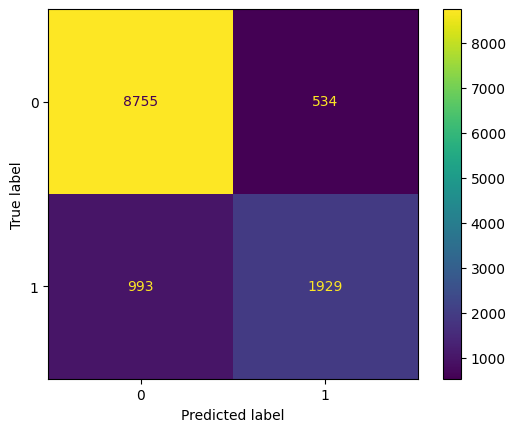

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

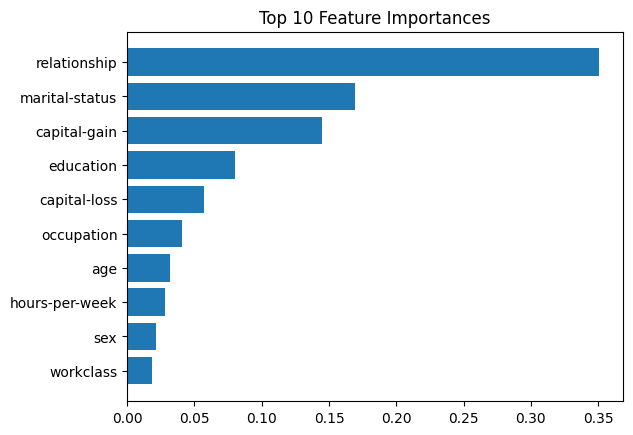

In [ ]:
importances = model.feature_importances_
feature_names = X.columns
indices = importances.argsort()[-10:]
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Top 10 Feature Importances")
plt.show()

# Regression:

In [ ]:
data_reg = fetch_openml(name='house_prices', version=1, as_frame=True)
df_house = data_reg.frame
df_house

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
X = df_house.drop('SalePrice', axis = 1)
y = df_house['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 10)
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [ ]:
model = XGBRegressor(n_estimators = 350, max_depth = 3, colsample_bytree  = 0.8, subsample = 0.8, learning_rate = 0.045,random_state = 10)
y_train_log = np.log1p(y_train)
model.fit(X_train, y_train_log)
pred_train_y_log = model.predict(X_train)
pred_train_y = np.expm1(pred_train_y_log)
pred_log = model.predict(X_test)
pred_y = np.expm1(pred_log)

In [ ]:
mae_train = mean_absolute_error(y_train, pred_train_y)
mae_test = mean_absolute_error(y_test, pred_y)
mse_train = mean_squared_error(y_train, pred_train_y)
mse_test = mean_squared_error(y_test, pred_y)
r2 = r2_score(y_test, pred_y)
print("TRAIN")
print(mae_train, mse_train)
print("TEST")
print(mae_test, mse_test, r2)

TRAIN
8528.53515625 149697376.0
TEST
16059.8125 627845568.0 0.9015944600105286


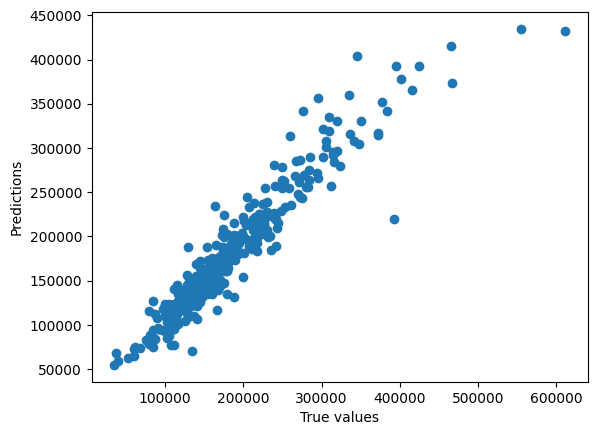

In [ ]:
plt.scatter(y_test, pred_y)
plt.xlabel("True values")
plt.ylabel("Predictions")
plt.show()

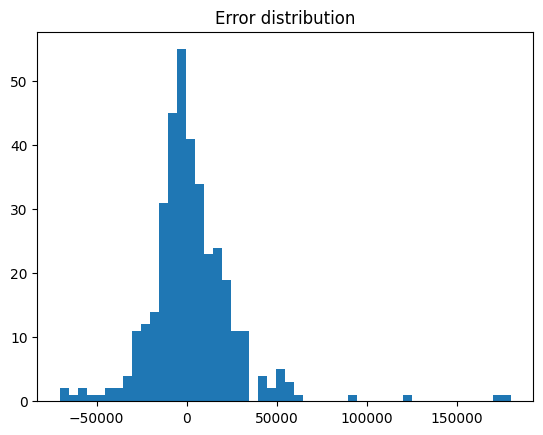

In [ ]:
errors = y_test - pred_y

plt.hist(errors, bins=50)
plt.title("Error distribution")
plt.show()